### **4.1 Autoregressive Forecasting**

In this activity, you will learn how to build an **autoregressive forecasting model** using real-world data.

An Australian fish and chip shop is planning to open a restaurant at Grand Central Station, New York. To assess the viability of the business, the woners want to estimate how many people pass by the station on a regular basis.

Suppose we have access to weekly foot traffic data. Our goal is to use this historical data to predict the number of future visitors over the next year using an autoregressive model.

We will use a modified version of the [NY Traffic Volume Counts](https://www.kaggle.com/datasets/new-york-city/ny-traffic-volume-counts-2012-2013), which as been transformed into weekly totals from 1968 to 2021. The dataset has been cleaned and prepared for forecasting.

---

**Data Description**

- File: GrandCentralVolume.csv
- Date format: yyyy-mm-dd
- NumTraffic: Weekly number of people passing by Grand Central Station, measured in thousands (k)

**Tools and Libraries**

- `statsmodels` - for building autoregressive time series models
- `matplotlib` - for visualising the data and forecasts

**Responsible AI Principles**

The dataset does not include protected attributes such as race, gender, or income. Since the data consists of recorded observations (dates and counts), no additional bias is introduced during processing.

**Model Identification Flow**

The diagram below outlines the decision process for identifying whether a time series follows an **autoregressive (AR)**, **moving average (MA)**, or **random walk** pattern. It guides you through checking for **stationarity**, examining **autocorrelation** via ACF and PACF plots, and selecting the appropriate model based on where the autocorrelations become non-significant.

<img src="Autoregression_Model_Identification.png" alt="Autoregression Model Identification" width="700">

#### **Part 1: Time Series Type Identification**

**Step 1: Import all the libraries, read the data and explore observed data**

Before we begin modelling, we need to upload the two datasets provided on the course website:

- `GrandCentralVolume.csv` - weekly foot traffic near Grand Central Station

- `FootTrafficToo.csv` - a second dataset for later comparison and exercises


In [14]:
# Time series tools from the statsmodels library
from statsmodels.tsa.stattools import adfuller         # for stationarity testing
from statsmodels.tsa.statespace.sarimax import SARIMAX # for advanced modelling
from statsmodels.graphics.tsaplots import plot_acf     # for autocorrelation plots
from statsmodels.graphics.tsaplots import plot_pacf    # for partial autocorrelation plots

# Data manipulation
import pandas as pd
import numpy as np

# Machine learning tools from the scikit-learn library
from sklearn.metrics import mean_squared_error

# Plotting library
%matplotlib inline
import matplotlib.pyplot as plt

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")

In [4]:
# Read the primary dataset
df = pd.read_csv("./data/GrandCentralVolume.csv", parse_dates=['Date'], index_col='Date')

In [5]:
# Display the first few rows of the dataset to understand its structure
df.head()

,NumTraffic
Date,
1968-01-01,500
1968-01-08,501
1968-01-15,501
1968-01-22,503
1968-01-29,504


In [6]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2811 entries, 1968-01-01 to 2021-11-08
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   NumTraffic  2811 non-null   int64
dtypes: int64(1)
memory usage: 43.9 KB


We have:

- A DataFrame with **2,811 weekly observations** spanning from **1968-01-01 to 2021-11-08**.

- The `Date` column has been successfully converted to a **Datetime Index**, which enables time series operations.

- The dataset contains one variable `NumTraffic`, representing the weekly foot traffic counts (in thousands).

- There are **no missing values**, and the data is ready for analysis.

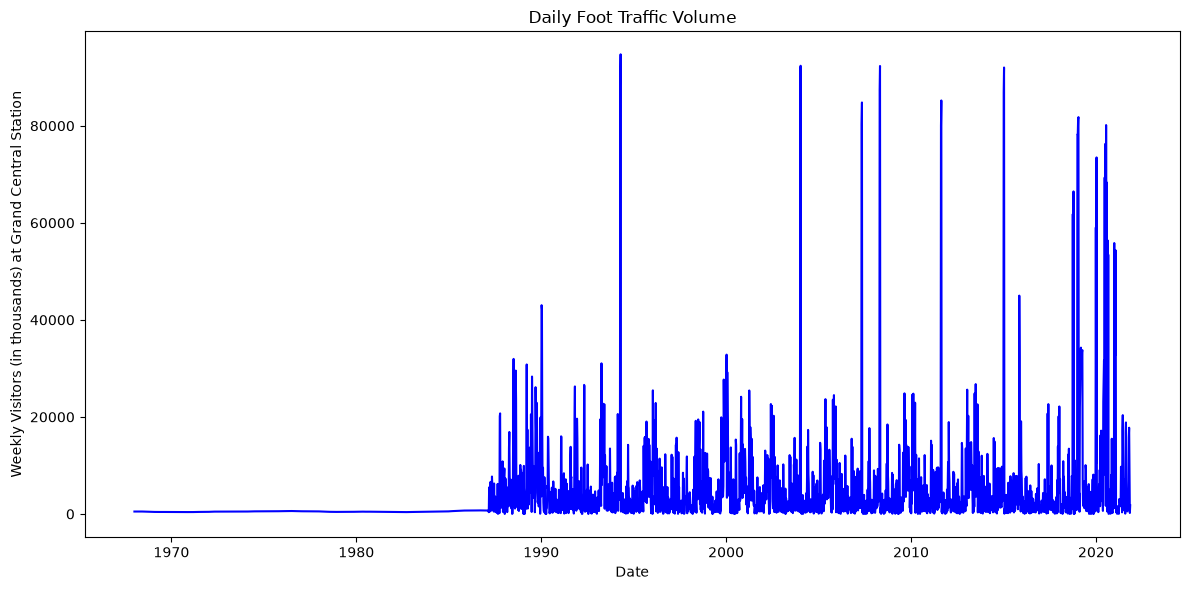

In [9]:
# Plot the time series data to visualize trends and seasonality
plt.figure(figsize=(12, 6))

plt.plot(df.index, df['NumTraffic'], label='Daily Volume', color='blue')
plt.xlabel('Date')
plt.ylabel('Weekly Visitors (in thousands) at Grand Central Station')
plt.title('Daily Foot Traffic Volume')
plt.tight_layout()
plt.show()

**What do you observe in this graph?**

- Is it a stationary process?
- Does it show a trend?
- Does it show seasonality?

<span style="color:orange">

**Step 2: Test for Stationarity**

Before applying autoregressive models, we check whether the time series is **stationary** using the **Augmented Dickey-Fuller (ADF) test**.

- Null hypothesis ($H_{0}$): The series is non-stationary (has a unit root).

- Alternative hypothesis ($H_{1}$): The series is stationary.

If the **p-value** is less than 0.05, we **reject the null** and conclude that the series is likely stationary. Otherwise, we may need to transform or difference the data before modelling.
</span>

In [10]:
# Apply Augmented Dickey-Fuller test to check for stationarity
ADF_result = adfuller(df['NumTraffic'])
print('ADF Statistic:', ADF_result[0])
print('p-value:', ADF_result[1])
print('Critical Values:', ADF_result[4])

ADF Statistic: -6.100299870815839
p-value: 9.872485498982248e-08
Critical Values: {'1%': np.float64(-3.432702747682219), '5%': np.float64(-2.862579477749862), '10%': np.float64(-2.56732334640735)}


As the p-value of the ADF is significant ($\le0.05$), it suggests that it is **stationary**.

**Step 3: Plot Autocorrelation**

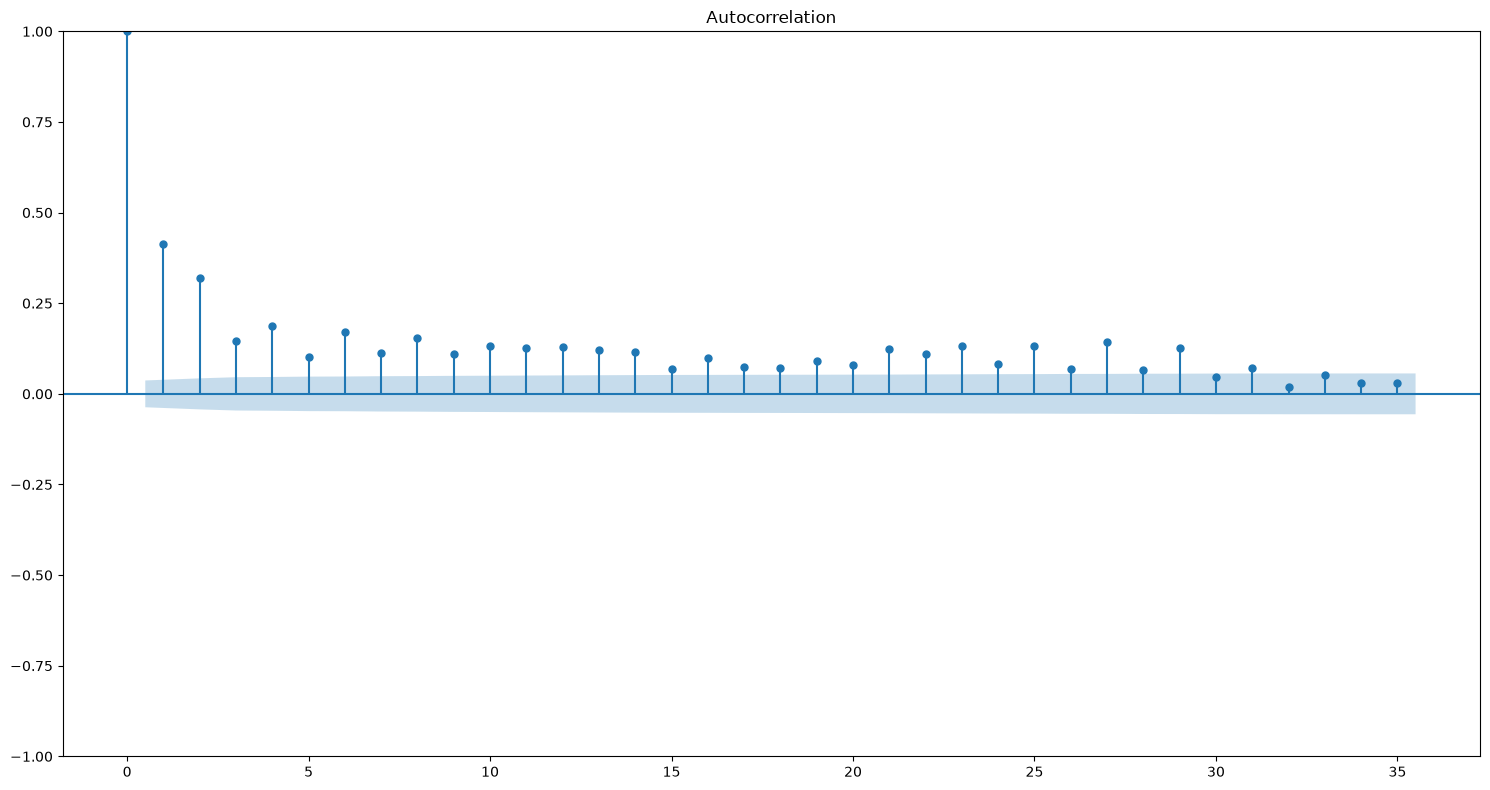

In [13]:
# Plot the autocorrelation function (ACF) for the time series data
# ACF shows how current values are correlated with past values at different lags
fig = plot_acf(df['NumTraffic'])
fig.set_size_inches(15, 8)
plt.tight_layout()
plt.show()

**Note**: The ACF shows a gradual decline, which suggests the series is **not an MA(q) process**. Next, we will check the PACF to see if the pattern fits an **AR(p) model**.

**Step 4: Partial ACF (PACF)**

Autoregression is based on the idea that the current value of a time series can be predicted using **past values** of that same series - the present value is essentially a **weighted average of previous observations**.

To determine how many past values to include in the model (i.e. the **order** `p` in an AR(p) model), we use the **Partial Autocorrelation Function (PACF)**.

PACF helps identify the **optimal lag structure** by showing the direct correlation between a time point and its lagged versions, **after removing the effect of shorter lags**. Significant spikes in the PACF plot indicate useful lags for the autoregressive model.

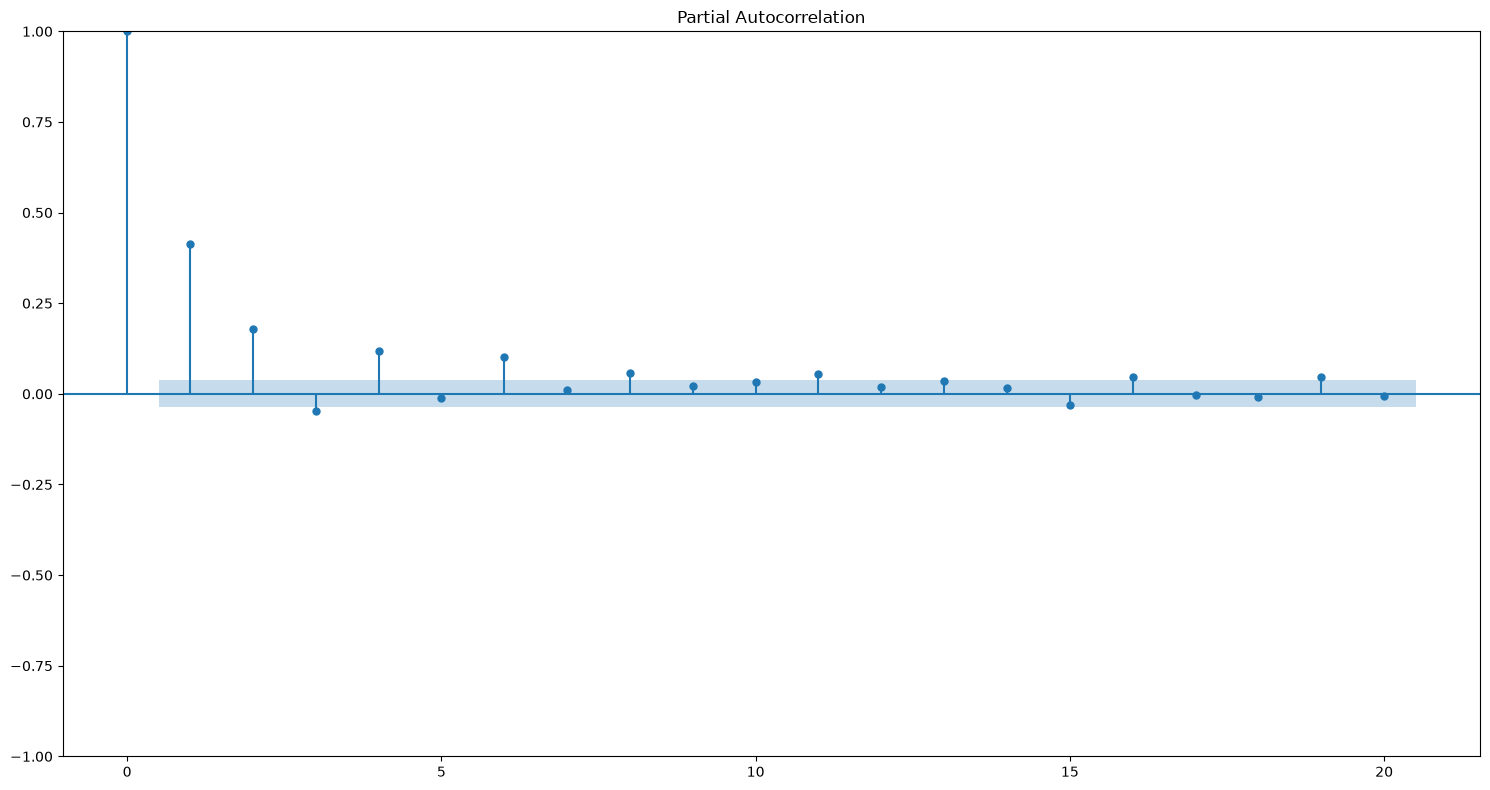

In [15]:
# Plot the Partial Autocorrelation Function (PACF) for the time series data
# Using lags=20 to visualize the first 20 lags

fig = plot_pacf(df['NumTraffic'], lags=20)
fig.set_size_inches(15, 8)
plt.tight_layout()
plt.show()

**Note**:

The PACF plot shows clear spikes at **lags 1 and 2**, indicating strong autoregressive structure.

- **Lag 6** also appears to be **marginally significant**, suggesting it may contribute additional predictive power.

- Most other lags fall within the confidence interval, so we do **not** consider them significant.

Based on this, an **AR(2)** or **AR(6)** model could be reasonable starting points, depending on further model evaluation.

#### **Part 2: Forecasting with an Autoregressive Model**

We now split the dataset into **training** and **testing** sets.

We will use the most recent 52 weeks (1 year) as the **test set**, and all earlier data for **training** the model.

In [16]:
# Split the data into training and testing sets
# Use the last 52 weeks (1 year) as the test set
train = df.iloc[:-52]
test = df.iloc[-52:]

# Print the number of observations in the training and testing sets
print(f'Training set size: {len(train)}')
print(f'Testing set size: {len(test)}')

Training set size: 2759
Testing set size: 52


**Rolling Forecast Function**

We define a rolling forecast function that simulates how predictions would be made in a real-world scenario.

At each time step, the model is updated using all available data up to that point, and a prediction is made for the next time period.

The function supports:

- **Mean**: Forecast is the mean of all previous values.

- **Last**: Forecast is the last observed value.

- **AR**: Fits an AR(6) model using SARIMAX and predicts one step ahead.

This is called an **expanding window forecast**, where the training set grows with each iteration.

In [19]:
def rolling_forecast(df2: pd.DataFrame, train_len: int, horizon: int, window: int, method: str):
    """
    Perform rolling forecast using the specified method: mean, last, or AR(6).
    
    Parameters:
    - df2: DataFrame containing the time series data.
    - train_len: Length of the training set.
    - horizon: Number of steps to forecast (e.g. 52 weeks).
    - window: How many steps to forecast at each iteration (usually 1).
    - method: Forecasting method ('mean', 'last', or 'AR').
    
    Returns:
    - predictions: List of forecasted values for the test set horizon.
    """
    total_len = train_len + horizon

    if method == "mean":
        pred_mean = []
        for i in range(train_len, total_len, window):
            mean = np.mean(df2[:i].values)
            pred_mean.extend([mean] * window)
        return pred_mean
    
    elif method == "last":
        pred_last_value = []
        for i in range(train_len, total_len, window):
            last_value = df2[:i].iloc[-1].values[0]
            pred_last_value.extend([last_value] * window)
        return pred_last_value
    
    elif method == "AR":
        pred_AR = []
        for i in range(train_len, total_len, window):
            model = SARIMAX(df2[:i], order=(6, 0, 0), enforce_stationarity=False)
            res = model.fit(disp=False)
            predictions = res.get_prediction(start=0, end=i + window - 1)
            oos_pred = predictions.predicted_mean.iloc[-window:]
            pred_AR.extend(oos_pred)
        return pred_AR
        

**Model Training and Forecasting**

We now use the rolling forecast function to generate predictions for the test period (52 weeks) using:

- The historical **mean**.
- The **last observed value**.
- And an **autoregressive model (AR(6)).

Each model is retrained at every time step to simulate a realistic forecasting scenario.

In [20]:
# Set key parameters for the rolling forecast
TRAIN_LEN = len(train)  # Length of the training set
HORIZON = len(test)  # Number of steps to forecast (e.g., 52 weeks)
WINDOW = 1  # How many steps to forecast at each iteration

# Generate forecasts using each method
pred_mean = rolling_forecast(df, TRAIN_LEN, HORIZON, WINDOW, method="mean")
pred_last_value = rolling_forecast(df, TRAIN_LEN, HORIZON, WINDOW, method="last")
pred_AR = rolling_forecast(df, TRAIN_LEN, HORIZON, WINDOW, method="AR")

# Add predictions to the test DataFrame for comparison
test['pred_mean'] = pred_mean
test['pred_last_value'] = pred_last_value
test['pred_AR'] = pred_AR

# Preview the test DataFrame with actual and predicted values
test.head()

,NumTraffic,pred_mean,pred_last_value,pred_AR
Date,,,,
2020-11-16,910,3958.489308,15502,5998.568599
2020-11-23,199,3957.384783,910,3864.866982
2020-11-30,3323,3956.023542,199,-603.635189
2020-12-07,2335,3955.794352,3323,4095.186421
2020-12-14,1157,3955.207745,2335,1488.346234


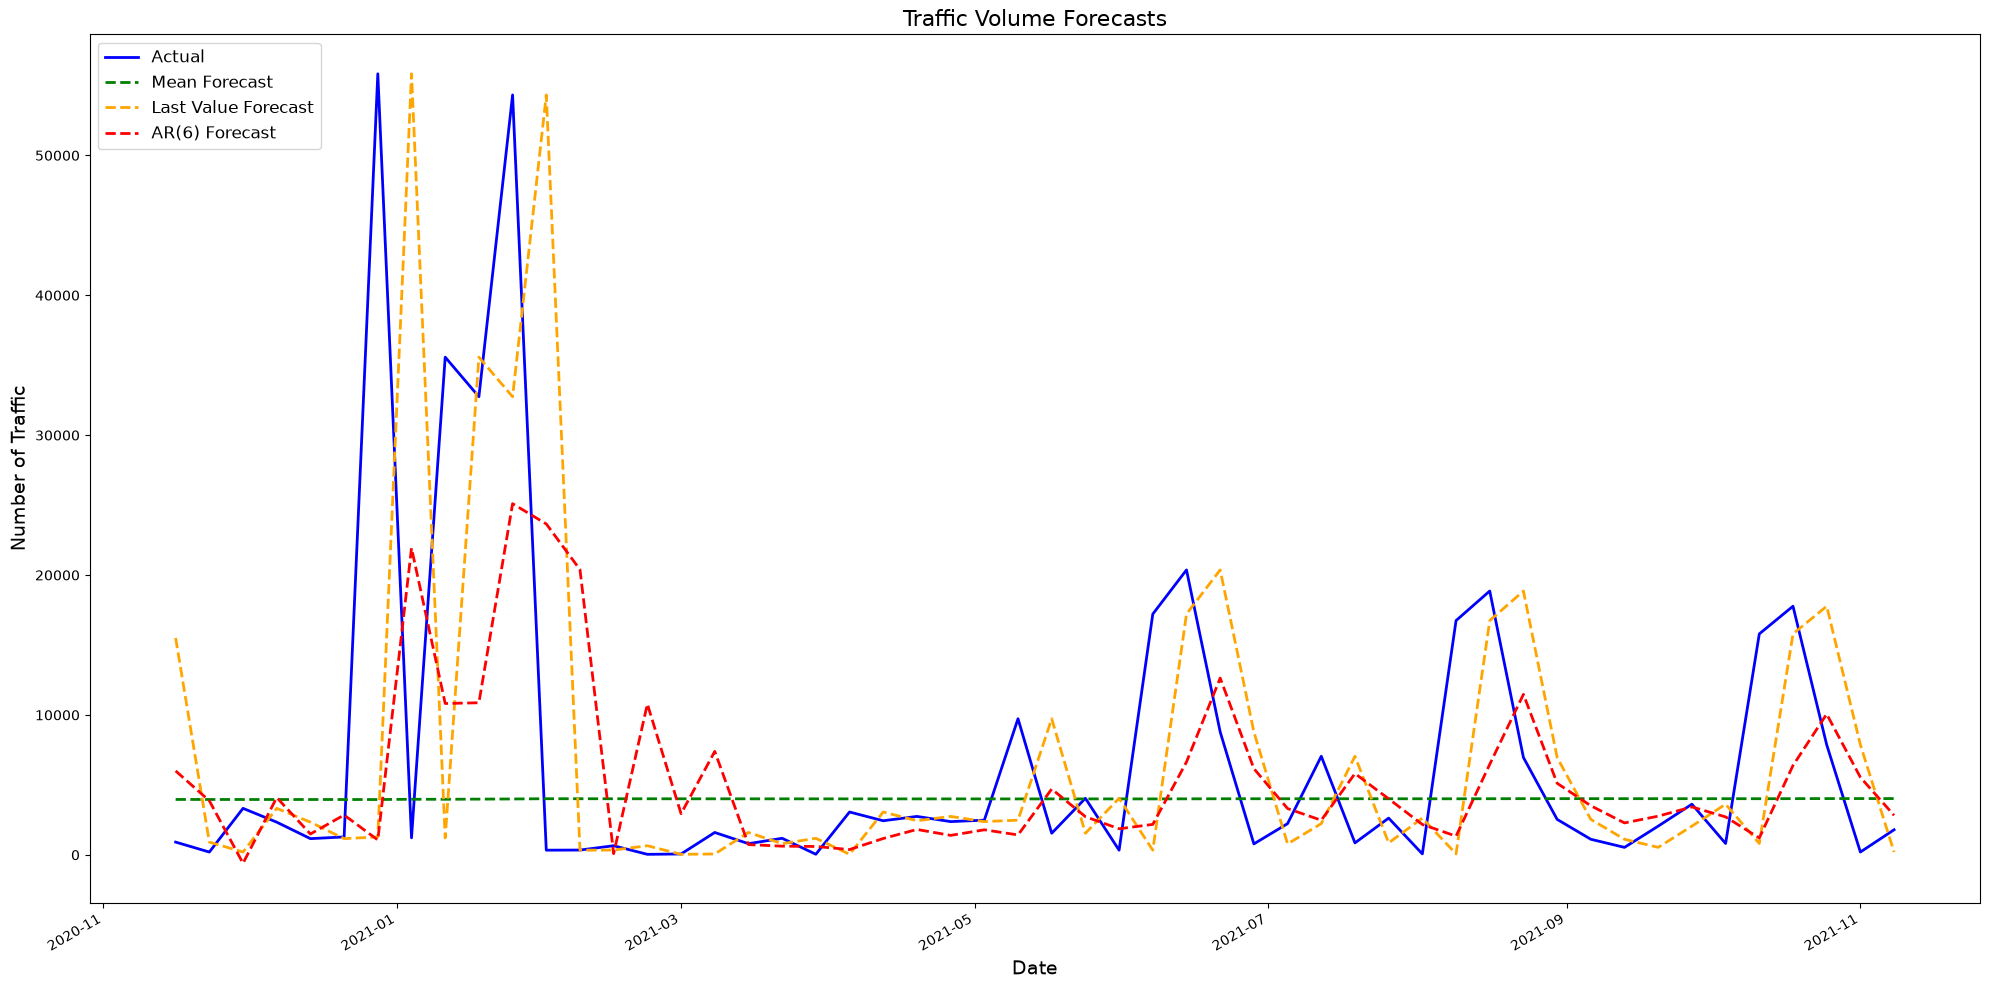

In [21]:
# Plot actual traffic volume against the predictions from each method
fig, ax = plt.subplots(figsize=(20, 10))

# Actual traffic volume
ax.plot(test.index, test['NumTraffic'], label='Actual', color='blue', linewidth=2)

# Forecasts
ax.plot(test.index, test['pred_mean'], label='Mean Forecast', color='green', linestyle='--', linewidth=2)
ax.plot(test.index, test['pred_last_value'], label='Last Value Forecast', color='orange', linestyle='--', linewidth=2)
ax.plot(test.index, test['pred_AR'], label='AR(6) Forecast', color='red', linestyle='--', linewidth=2)

ax.set_title('Traffic Volume Forecasts', fontsize=16)
ax.set_xlabel('Date', fontsize=14)
ax.set_ylabel('Number of Traffic', fontsize=14)
ax.legend(loc='upper left', fontsize=12)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

This plot compares the actual weekly foot traffic against three forecasting models:

- **Mean Forecast**: A flat line based on historical average.
- **Last Value Forecast**: A naive model that repeats the most recent value.
- **AR(6) Forecast**: An autoregressive model using the past 6 lags.

We can now visually assess which model better tracks recent changes in the data.

In [27]:
# Calculate Mean Squared Error (MSE) for each forecasting method
mse_mean = mean_squared_error(test['NumTraffic'], test['pred_mean'])
mse_last_value = mean_squared_error(test['NumTraffic'], test['pred_last_value'])
mse_AR = mean_squared_error(test['NumTraffic'], test['pred_AR'])

# Print the MSE results for each method
print(f"{'Forecast Method':<30} {'MSE':>15}")
print('-' * 46)
print(f'{"Mean Forecast":<30} {mse_mean:>15,.2f}')
print(f'{"Last Value Forecast":<30} {mse_last_value:>15,.2f}')
print(f'{"Autoregressive Forecast":<30} {mse_AR:>15,.2f}')

Forecast Method                            MSE
----------------------------------------------
Mean Forecast                   164,948,999.48
Last Value Forecast             236,929,162.62
Autoregressive Forecast         152,915,886.58


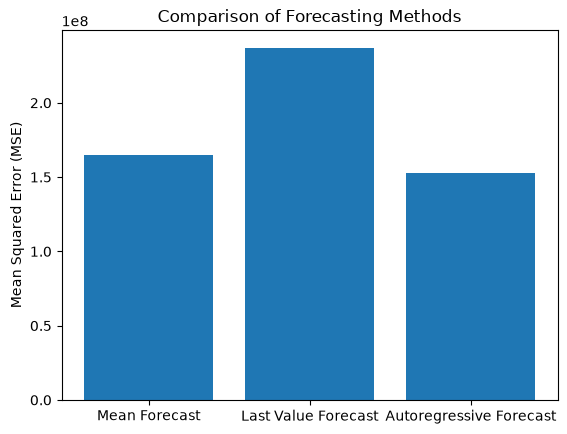

In [28]:
# Plot MSE values for each forecasting method for visual comparison
methods = ['Mean Forecast', 'Last Value Forecast', 'Autoregressive Forecast']
mse_values = [mse_mean, mse_last_value, mse_AR]

plt.bar(methods, mse_values)
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Comparison of Forecasting Methods')
plt.show()

**Note**: Since we did **not apply any transformations** (e.g. log or standard scaling), the forecasts and actual values are already in the **original scale**. This means error metrics like MSE can be directly interpreted without needing to invert or rescale the data.

---

**Note**: In this practical, we focused on a simplified **AR modelling** workflow and skipped log transformation and seasonality analysis. The data appeared stable enough, and our goal was to highlight core forecasting concepts.

However, in real-world scenarios, it is good practice to ask:

- Does the variance suggest a transformation is needed?

- Are there seasonal patterns (e.g. yearly) worth modelling?

#### **Part 3: What if we did the differenced transformation?**

We would need to reverse the transformation for it to make sense.

Here is an example. **Assume that our data is not stationary. This data is fictional data. Let's apply differenced transformation to our data**.

In [29]:
# Read the data
df2 = pd.read_csv("./data/FootTrafficToo.csv", parse_dates=['Date'], index_col='Date')

In [30]:
df2.head()

,Foot_traffic
Date,
2013-04-09,500
2013-04-10,501
2013-04-11,501
2013-04-12,503
2013-04-13,504


In [31]:
df2.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1000 entries, 2013-04-09 to 2016-01-03
Data columns (total 1 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Foot_traffic  1000 non-null   int64
dtypes: int64(1)
memory usage: 15.6 KB


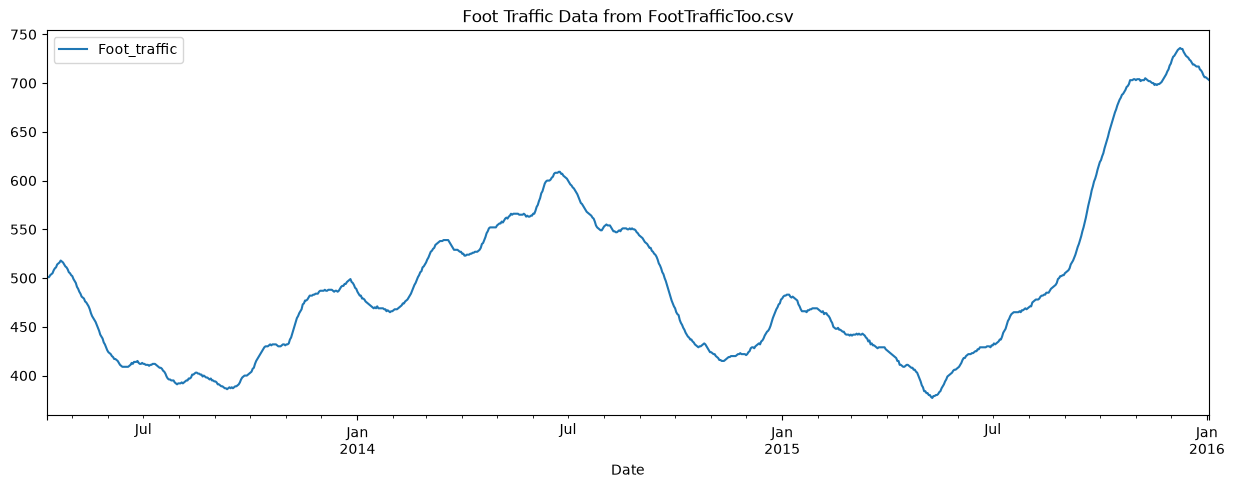

In [ ]:
# Plot the data
df2.plot(figsize=(15, 5))
plt.title('Foot Traffic Data from FootTrafficToo.csv')
plt.show()

**What do you observe in this graph?**

- Is it a stationary process?
- Does it show a trend?
- Does it show seasonality?